In [1]:
from pathlib import Path
import sys

sys.path.append('..')
from utils import draw_pr_curve_from_cv_results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import stumpy
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_validate, StratifiedKFold
from aeon.transformations.collection import Normalizer
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV

In [5]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 4)})

In [6]:
data_dir = Path('../../results')

df = pd.read_csv(data_dir / 'train_ts.csv', index_col='id').reset_index(drop=True)
df['action'] = df['genre'].map(lambda x: 'Action' in x)
train_X = Normalizer().fit_transform(df[[str(i) for i in range(100)]])
train_X = pd.DataFrame(train_X.reshape(850, 100))
train_y = df['action']

We split our data into the action_df, and not_action_df and concatenate all the individual samples of each respective class into one long time series (after amplitude scaling). We also establish a clear boundary for each sample appending `NaN` at the end in order to avoid finding spurious patterns across time series.

In [7]:
action_df = (train_X[train_y]
             .assign(NaN=np.nan)
             .stack(dropna=False).to_frame().reset_index(drop=True)
             .rename({0: 'Box Office'}, axis='columns'))
no_action_df = (train_X[~train_y]
                .assign(Nan=np.nan)
                .stack(dropna=False).to_frame().reset_index(drop=True)
                .rename({0: 'Box Office'}, axis='columns'))

/tmp/ipykernel_2533338/435047632.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False).to_frame().reset_index(drop=True)
/tmp/ipykernel_2533338/435047632.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False).to_frame().reset_index(drop=True)


We present the idea graphically with a subset of examples.

In [8]:
limit = 1210

/tmp/ipykernel_2533338/1574589128.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_2533338/1574589128.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


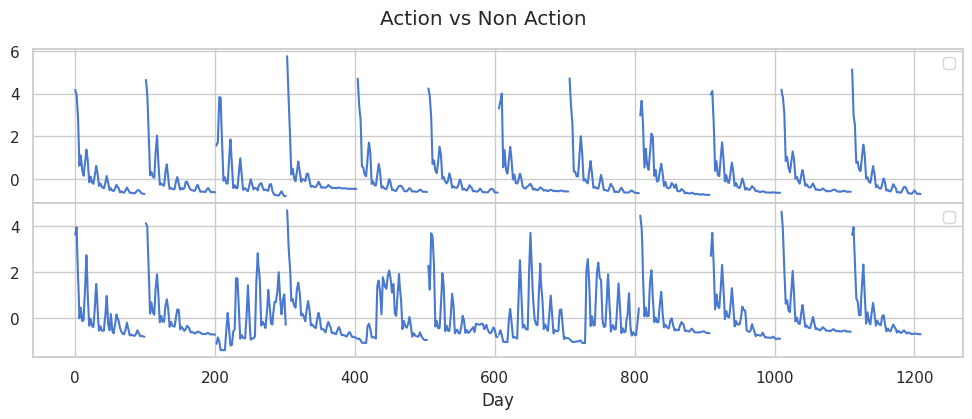

In [9]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Action vs Non Action')
plt.xlabel('Day')

axs[0].plot(action_df[:limit])
axs[0].legend()

axs[1].plot(no_action_df[:limit])
axs[1].legend()

A matrix profile $P_{AA}$ calculated from a single time series $T_A$ (self-join) allows us to identify conserved subsequences within $T_A$.

A matrix profile $P_{AB}$ computed across two different time series $T_A$ and $T_B$ (AB-join) compares all hte subsequences of $T_A$ with all the subsequences in $T_B$ in order to determine if there are any subsequences in $T_A$ that can also be found in $T_B$.

If a discriminative patter is present in the `Action` class but not in the `non Action` class, then we should expect to see significant differences in heights in the matrix profiles.

In [10]:
m = 28
P_Action_Action = stumpy.stump(action_df['Box Office'], m).P_.astype(float)
P_Action_NoAction = stumpy.stump(action_df['Box Office'], m, no_action_df['Box Office'],
                                 ignore_trivial=False).P_.astype(float)
P_NoAction_NoAction = stumpy.stump(no_action_df['Box Office'], m).P_.astype(float)
P_NoAction_Action = stumpy.stump(no_action_df['Box Office'], m, action_df['Box Office'],
                                 ignore_trivial=False).P_.astype(float)

In [11]:
P_Action_Action[P_Action_Action == np.inf] = np.nan
P_Action_NoAction[P_Action_NoAction == np.inf] = np.nan
P_NoAction_NoAction[P_NoAction_NoAction == np.inf] = np.nan
P_NoAction_Action[P_NoAction_Action == np.inf] = np.nan

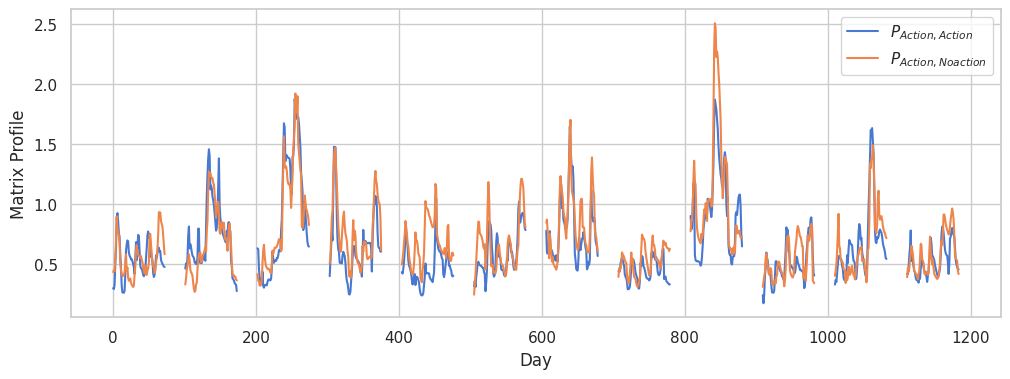

In [12]:
plt.plot(P_Action_Action[:limit], label="$P_{Action,Action}$")
plt.plot(P_Action_NoAction[:limit], label="$P_{Action,No action}$")
plt.xlabel('Day')
plt.ylabel('Matrix Profile')
plt.legend()
plt.show()

We highlight the major deviations between the two matrix profiles by plotting the difference between $P_{Action,Action}$ and $P_{Action,NonAction}$.

Text(0.5, 1.0, '$P_{diff} = P_{Action,NoAction} - P_{Action,Action}$')

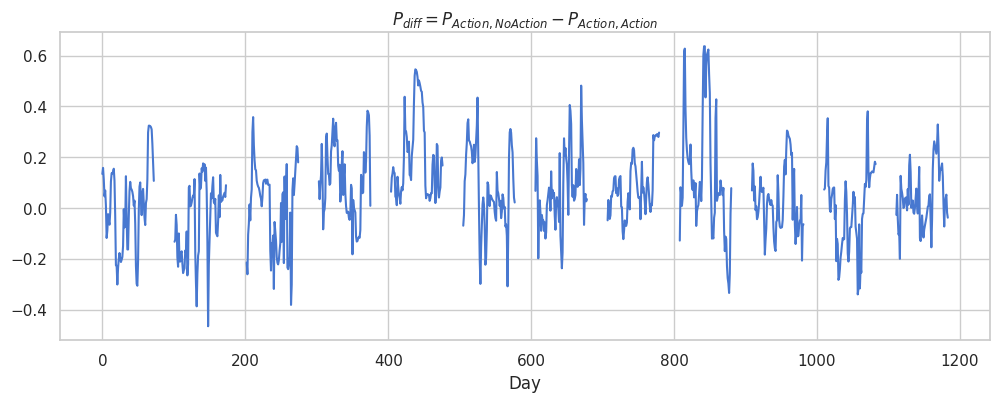

In [13]:
P_diff = P_Action_NoAction - P_Action_Action
P_diff_r = P_NoAction_Action - P_NoAction_NoAction

plt.plot(P_diff[:limit])
plt.suptitle('')
plt.xlabel('Day')
plt.title("$P_{diff} = P_{Action,NoAction} - P_{Action,Action}$")


Peak values in $P_{diff}$ are indicators of good shapelets candidates because they suggest pattern that are well conserved in their own class but are also very different from their closes match in the other class.

In [14]:
def distance_to_shapelet(data, shapelet):
    """Compute the minimum distance between each data sample and a shapelet"""
    data = np.asarray(data)
    X = np.empty(len(data))
    for i in range(len(data)):
        D = stumpy.mass(shapelet, data[i])
        X[i] = D.min()
    return X

In [15]:
def shapelet_transformer(ts_data, shapelets):
    X = pd.DataFrame()
    for i, shapelet in enumerate(shapelets):
        X[i] = distance_to_shapelet(ts_data, shapelet)
    return X

We extract 10 candidate shapelets for each class.

In [16]:
n_shapelets = 10
action_shapelets = []
no_action_shapelets = []

idx_action = np.argpartition(np.nan_to_num(P_diff), -n_shapelets)[-n_shapelets:] # get the top 10 peak locations in P_diff
idx_no_action = np.argpartition(np.nan_to_num(P_diff_r), -n_shapelets)[-n_shapelets:]

for i, j in zip(idx_action, idx_no_action):
    shapelet = action_df.iloc[i : i + m, 0]
    action_shapelets.append(shapelet)
    shapelet = no_action_df.iloc[i : i + m, 0]
    no_action_shapelets.append(shapelet)

shapelets = action_shapelets + no_action_shapelets

train_X_sh = shapelet_transformer(train_X, shapelets)

## Selection of top shapelets

We use Recursive feature elimination in order to determine the ranking of the feature and then we test the model using n top features in order to determine the optimal selection of features.

In [17]:
cv = StratifiedKFold()
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)

rfecv = RFECV(clf,
              step=1,
              scoring='f1',
              min_features_to_select=1,
              n_jobs=-1)

rfecv.fit(train_X_sh, train_y)
print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 6


Text(0, 0.5, 'Mean test f1 score')

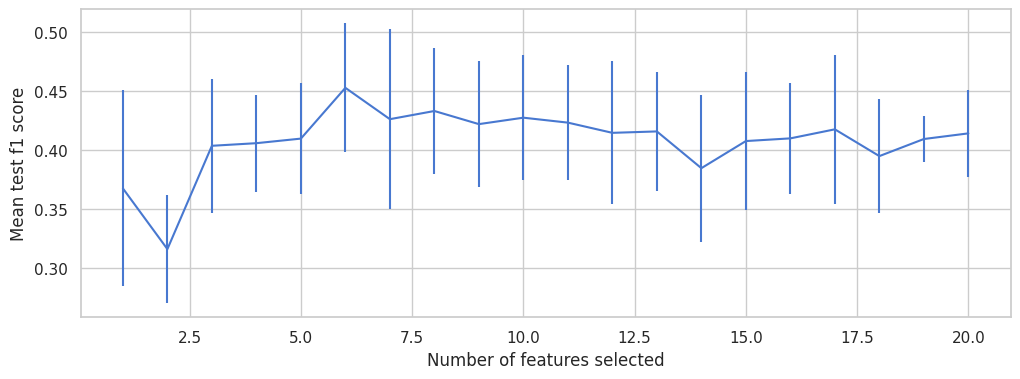

In [18]:
data = {
    key: value
    for key, value in rfecv.cv_results_.items()
    if key in ['n_features', 'mean_test_score', 'std_test_score']
}

cv_results = pd.DataFrame(data)
plt.errorbar(
    x=cv_results['n_features'],
    y=cv_results['mean_test_score'],
    yerr=cv_results['std_test_score']
)
plt.xlabel('Number of features selected')
plt.ylabel('Mean test f1 score')

In [19]:
from collections import Counter

In [20]:
feats = []
for i in range(cv.n_splits):
    mask = rfecv.cv_results_[f'split{i}_support'][
        rfecv.n_features_ - 1
    ] # mask of features selected by the RFE
    fold_feats = train_X_sh.columns[mask]
    print("Fold {i} features:", fold_feats)
    feats += list(fold_feats)
counter = Counter(feats)
counter.most_common()

Fold {i} features: Index([1, 4, 7, 10, 11, 14], dtype='int64')
Fold {i} features: Index([1, 9, 10, 11, 14, 18], dtype='int64')
Fold {i} features: Index([1, 4, 5, 6, 11, 14], dtype='int64')
Fold {i} features: Index([3, 4, 5, 10, 11, 14], dtype='int64')
Fold {i} features: Index([4, 7, 9, 11, 14, 18], dtype='int64')


[(11, 5),
 (14, 5),
 (4, 4),
 (1, 3),
 (10, 3),
 (7, 2),
 (9, 2),
 (18, 2),
 (5, 2),
 (6, 1),
 (3, 1)]

In [21]:
for min_folds in range(1, 6):
    selected_feats = [feat
                    for feat, count
                    in counter.most_common()
                    if count >= min_folds]
    cv_results = cross_validate(clf,
                                train_X_sh[selected_feats],
                                train_y,
                                scoring=('f1', 'precision', 'recall', 'average_precision'),
                                return_estimator=True,
                                return_indices=True)
    print(f"Results for shapelets with consensus in at least {min_folds}")
    for key, value in cv_results.items():
        if key.startswith('test_'):
            print(f"{key.replace('test_', '')}: {round(np.mean(value), 2)} ({round(np.std(value), 2)})")
    print()

Results for shapelets with consensus in at least 1
f1: 0.45 (0.07)
precision: 0.44 (0.06)
recall: 0.46 (0.11)
average_precision: 0.42 (0.05)

Results for shapelets with consensus in at least 2
f1: 0.45 (0.06)
precision: 0.45 (0.04)
recall: 0.46 (0.08)
average_precision: 0.4 (0.04)

Results for shapelets with consensus in at least 3
f1: 0.45 (0.08)
precision: 0.45 (0.05)
recall: 0.46 (0.11)
average_precision: 0.43 (0.04)

Results for shapelets with consensus in at least 4
f1: 0.4 (0.05)
precision: 0.42 (0.04)
recall: 0.39 (0.07)
average_precision: 0.39 (0.04)

Results for shapelets with consensus in at least 5
f1: 0.35 (0.04)
precision: 0.36 (0.04)
recall: 0.34 (0.03)
average_precision: 0.35 (0.03)



Not much difference in results. We go with shapelets that were ranked at the top in at least 2 folds. We also must notice that varying random state in this passage yields different results and different lists of shapelets, which means that many shapelets have a similar information gain.

In [22]:
selected_feats = [feat
                    for feat, count
                    in counter.most_common()
                    if count >= 2]
selected_feats

[11, 14, 4, 1, 10, 7, 9, 18, 5]

We now cross validate with this selection of features and observe results.

In [23]:
def print_cv_results(cv_results):
    for key, value in cv_results.items():
        if key.startswith('test'):
            print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

In [24]:
cv_results = cross_validate(clf, train_X_sh[selected_feats], train_y,
               scoring=('precision', 'recall', 'f1', 'average_precision'), return_estimator=True, return_train_score=True,
               return_indices=True)

In [25]:
print_cv_results(cv_results)

precision: 0.45 (0.04)
recall: 0.46 (0.08)
f1: 0.45 (0.06)
average_precision: 0.40 (0.04)


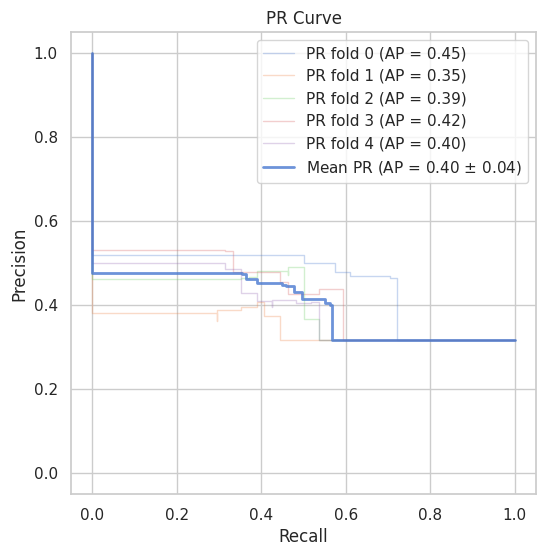

In [26]:
draw_pr_curve_from_cv_results(cv_results, train_X_sh[selected_feats], train_y)

## Another approach: ensemble of trees

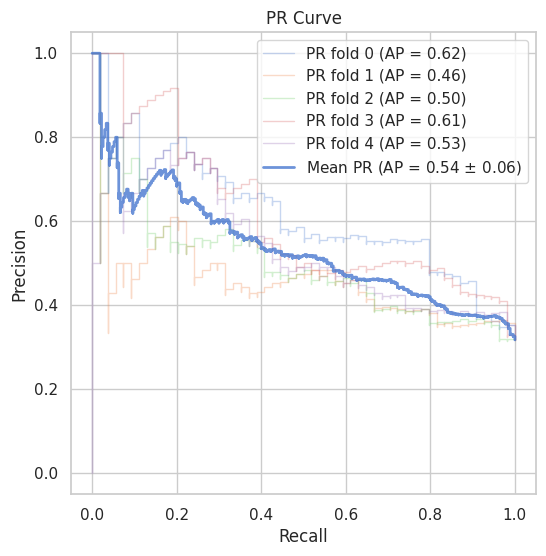

In [27]:
rf = RandomForestClassifier(n_estimators=50, min_samples_leaf=3, random_state=42)
rf_results = cross_validate(rf, train_X_sh, train_y,
                            scoring=('precision', 'recall', 'f1', 'average_precision'),
                            return_train_score=True,
                            return_estimator=True, return_indices=True)
draw_pr_curve_from_cv_results(rf_results, train_X_sh, train_y)

In [28]:
print_cv_results(rf_results)

precision: 0.60 (0.07)
recall: 0.33 (0.06)
f1: 0.42 (0.06)
average_precision: 0.54 (0.06)


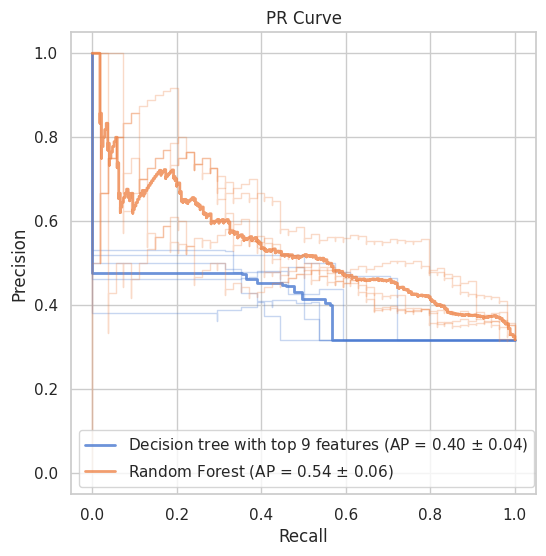

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
draw_pr_curve_from_cv_results(cv_results, train_X_sh[selected_feats], train_y, ax=ax, color='C0', name='Decision tree with top 9 features')
draw_pr_curve_from_cv_results(rf_results, train_X_sh, train_y, ax=ax, color='C1', name='Random Forest')
ax.legend()
plt.show()


Random forest PR curve always dominates the decision tree with selected features. We should also notice that performance on different folds shows considerable variation.

## Shapelet analysis

In [30]:
rf.fit(train_X_sh, train_y)
print(rf.feature_importances_.argsort())

[ 6  8  7 19  1 16 18 15  9  0  4 12  5 17  2  3 10 13 11 14]


Top four shapelets are shapelets for the **negative** class. As we noticed during clustering, movies of the 'Twelve years a Slave' type, that have a distinctive shape, tend not to be action movies.

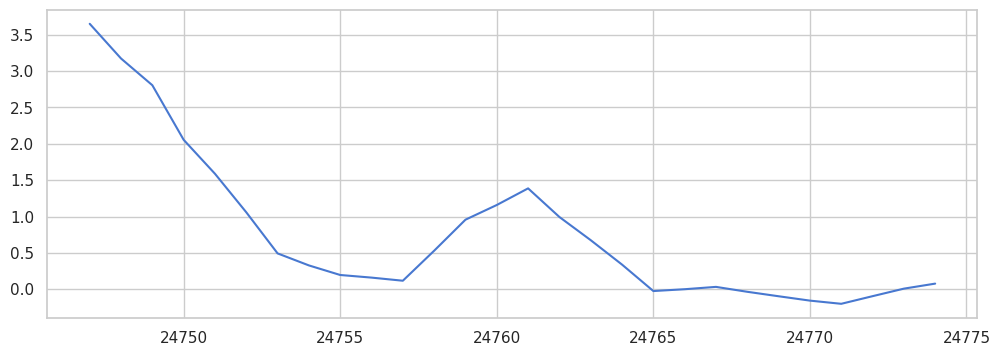

In [31]:
plt.plot(shapelets[14])

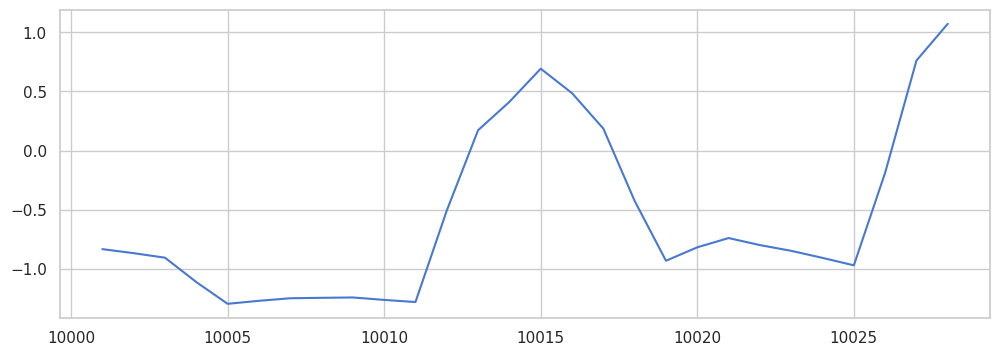

In [32]:
plt.plot(shapelets[11])

Here we can see two major peaks with a positive trend that is a pattern that generally doesn't occur in movies of the 'Mad Max' type, that have a negative trend with top profits in the first days after the release.

## Tune decision threshold

In [33]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [34]:

tuned_model = TunedThresholdClassifierCV(rf,scoring='f1')
tuned_model.fit(train_X_sh, train_y)
print(f'{tuned_model.best_threshold_=:.2f}')

tuned_model.best_threshold_=0.31


In [35]:
print(tuned_model.best_score_)

0.55477061167442


## Test

We expect the model performance to degrade on the test set, since we probably overfitted on the validation set, performing model selection and shapelet extraction on the same set.

In [36]:
test_df = pd.read_csv(data_dir / 'test_ts.csv', index_col='id').reset_index(drop=True)
test_df['action'] = test_df['genre'].map(lambda x: 'Action' in x)
test_X = Normalizer().fit_transform(test_df[[str(i) for i in range(100)]])
test_X = pd.DataFrame(test_X.reshape(len(test_df), 100))
test_y = test_df['action']

In [37]:
test_X_sh = shapelet_transformer(test_X, shapelets)

In [38]:
y_pred = tuned_model.predict(test_X_sh)
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.59      0.69       195
        True       0.46      0.74      0.56        89

    accuracy                           0.64       284
   macro avg       0.64      0.67      0.63       284
weighted avg       0.72      0.64      0.65       284

